# Análisis Topológico de Datos: Homología Persistente

### Objetivo
Aplicar **homología persistente** (H0 y H1) sobre el dataset preprocesado de ácido fólico y resultados perinatales para:
1. Detectar **componentes conexas** (H0) y **ciclos** (H1) en el espacio de datos multidimensional.
2. Comparar la topología del **subgrupo obesidad** (IMC ≥ 30) vs. normal/sobrepeso.
3. Relacionar características topológicas con riesgo perinatal (prematuridad, bajo peso).
4. Validar los subgrupos identificados con pruebas estadísticas y regresión logística.

### Variables utilizadas
| Variable | Descripción |
|---|---|
| `imc_pre` | IMC pregestacional materno (kg/m²) |
| `af_total` | Aporte total diario AF — suplementos + pan (mg/día) |
| `af_pan` | AF proveniente exclusivamente del pan (mg/día) |
| `af_sup_mg` | AF de suplementos clínicos (mg/día) |
| `eg` | Edad gestacional al parto (semanas) |
| `peso_rn` | Peso del recién nacido (g) |

Instalación de librerías

In [21]:
import subprocess, sys
for pkg in ['ripser', 'persim']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'])

Importación de librerías

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, chi2_contingency
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from matplotlib.lines import Line2D
import ripser
import persim
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.dpi': 120
})

PALETTE = {
    'primary':   '#2E5FA3',
    'secondary': '#E84855',
    'accent':    '#F4B942',
    'green':     '#3BB273',
    'light':     '#A8C5E8',
    'gray':      '#6C757D',
    'purple':    '#7B2D8B'
}


Carga del dataset

In [23]:
from pathlib import Path

# Carga
base = Path.cwd()
candidates = [
    base / 'Data' / 'Ingesta_AF_clean.csv',
    base.parent / 'Data' / 'Ingesta_AF_clean.csv',
    base / 'data' / 'Ingesta_AF_clean.csv',
    base.parent / 'data' / 'Ingesta_AF_clean.csv'
]

df = pd.read_csv(path)


print(f'Registros : {df.shape[0]:,}')
print(f'Variables : {df.shape[1]}')
print()
df.head(3)

Registros : 1,170
Variables : 73



,Cod,edad,region_chile,neduc,paridad,fnacimiento,Sexo,pnacer,Edad_gestacion ultimo hijo,sitgest,...,pnacer_raw,eg_raw,uf_af,n_panes,pnacer_num,eg_num,n_panes_num,prematuro,eg_cat,uso_supl
0,1,26.0,1,4,1,2015-01-15 00:00:00,2,3040,39,9,...,3040.0,39.0,1000.0,2.0,3040.0,39.0,2.0,0.0,39–40 (normal),Usó suplemento
1,2,36.0,1,6,2,2012-03-29 00:00:00,2,3875,39,5,...,3875.0,39.0,1000.0,3.0,3875.0,39.0,3.0,0.0,39–40 (normal),Usó suplemento
2,3,22.0,1,5,1,2011-11-22 00:00:00,1,2665,38,0,...,2665.0,38.0,NaN,2.0,2665.0,38.0,2.0,0.0,37–38 (temprano),No usó suplemento


In [24]:
# ── Variables de resultado (etiquetas — NO entran al TDA) ─────────────────────
df['bajo_peso_rn']      = (df['pnacer_num'] < 2500).astype(float)
df.loc[df['pnacer_num'].isna(), 'bajo_peso_rn'] = np.nan

df['resultado_adverso'] = ((df['prematuro'] == 1) | (df['bajo_peso_rn'] == 1)).astype(float)

# Categoría de suplementación para subgrupos
# uf_af en µg/día: sin supl = NO consumio=1, baja = <1000 µg, adecuada = ≥1000 µg
df['cat_supl'] = 'Sin suplemento'
df.loc[(df['NO consumio'] == 0) & (df['uf_af'] <  1000), 'cat_supl'] = 'Dosis baja (<1000 µg/d)'
df.loc[(df['NO consumio'] == 0) & (df['uf_af'] >= 1000), 'cat_supl'] = 'Dosis adecuada (≥1000 µg/d)'

print('Resumen de variables clave:')
print(f'  uf_af disponible    : {df["uf_af"].notna().sum():,}  '
      f'(media={df["uf_af"].mean():.0f} µg/d)')
print(f'  n_panes_num disp.   : {df["n_panes_num"].notna().sum():,}  '
      f'(media={df["n_panes_num"].mean():.1f} panes/d)')
print(f'  eg_num disponible   : {df["eg_num"].notna().sum():,}  '
      f'(media={df["eg_num"].mean():.1f} sem)')
print(f'  pnacer_num disp.    : {df["pnacer_num"].notna().sum():,}  '
      f'(media={df["pnacer_num"].mean():.0f} g)')
print()
print(f'Resultados neonatales (etiquetas):')
print(f'  Prematuros (<37 sem)    : {df["prematuro"].sum():.0f} / {df["prematuro"].notna().sum()}  '
      f'({df["prematuro"].mean()*100:.1f}%)')
print(f'  Bajo peso RN (<2500 g)  : {df["bajo_peso_rn"].sum():.0f} / {df["bajo_peso_rn"].notna().sum()}  '
      f'({df["bajo_peso_rn"].mean()*100:.1f}%)')
print(f'  Resultado adverso       : {df["resultado_adverso"].sum():.0f}  '
      f'({df["resultado_adverso"].mean()*100:.1f}%)')
print()
print('Categorías de suplementación:')
print(df['cat_supl'].value_counts().to_string())

Resumen de variables clave:
  uf_af disponible    : 647  (media=2729 µg/d)
  n_panes_num disp.   : 1,159  (media=2.1 panes/d)
  eg_num disponible   : 1,065  (media=38.5 sem)
  pnacer_num disp.    : 1,058  (media=3348 g)

Resultados neonatales (etiquetas):
  Prematuros (<37 sem)    : 94 / 1065  (8.8%)
  Bajo peso RN (<2500 g)  : 55 / 1058  (5.2%)
  Resultado adverso       : 115  (9.8%)

Categorías de suplementación:
cat_supl
Dosis adecuada (≥1000 µg/d)    610
Sin suplemento                 525
Dosis baja (<1000 µg/d)         35


Construcción del Espacio de TDA

In [25]:
TDA_INTAKE = [
    'uf_af', 'n_panes_num',
    'NO consumio', 'Antes del embarazo', 'Durante todo el embarazo',
    'Marraqueta', 'Hallulla', 'Pan molde integral'
]
OUTCOMES = ['eg_num', 'pnacer_num', 'prematuro', 'bajo_peso_rn', 'resultado_adverso']

# Requiere uf_af y n_panes_num completos; binarias → 0 si NaN
df_tda = df[TDA_INTAKE + OUTCOMES + ['cat_supl']].dropna(subset=['uf_af', 'n_panes_num']).copy()
for col in ['NO consumio', 'Antes del embarazo', 'Durante todo el embarazo',
            'Marraqueta', 'Hallulla', 'Pan molde integral']:
    df_tda[col] = df_tda[col].fillna(0)
df_tda = df_tda.reset_index(drop=True)

print(f'Registros en espacio TDA : {len(df_tda):,}')
print(f'  Con resultado adverso  : {df_tda["resultado_adverso"].notna().sum()}')
print(f'  Resultado adverso = 1  : {df_tda["resultado_adverso"].sum():.0f}  '
      f'({df_tda["resultado_adverso"].mean()*100:.1f}%)')
print()

# Normalización robusta
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(df_tda[TDA_INTAKE].values)

# PCA 2D para visualización
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ve    = pca.explained_variance_ratio_
print(f'Varianza explicada PCA — PC1: {ve[0]*100:.1f}%  PC2: {ve[1]*100:.1f}%  '
      f'Total: {ve.sum()*100:.1f}%')

Registros en espacio TDA : 642
  Con resultado adverso  : 642
  Resultado adverso = 1  : 60  (9.3%)

Varianza explicada PCA — PC1: 47.0%  PC2: 15.0%  Total: 61.9%


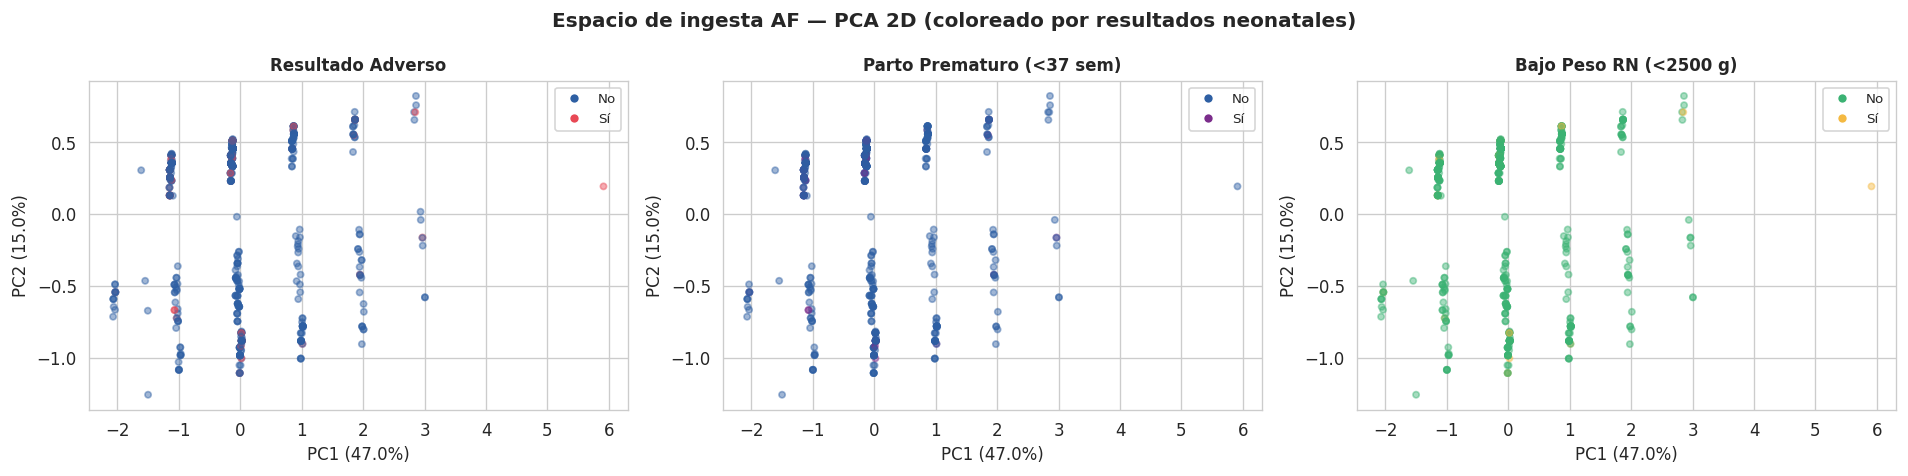

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Espacio de ingesta AF — PCA 2D (coloreado por resultados neonatales)',
             fontweight='bold')

for ax, col, title, c0, c1 in [
    (axes[0], 'resultado_adverso', 'Resultado Adverso',
     PALETTE['primary'], PALETTE['secondary']),
    (axes[1], 'prematuro',         'Parto Prematuro (<37 sem)',
     PALETTE['primary'], PALETTE['purple']),
    (axes[2], 'bajo_peso_rn',      'Bajo Peso RN (<2500 g)',
     PALETTE['green'],   PALETTE['accent']),
]:
    mask_v = df_tda[col].notna()
    colors = df_tda.loc[mask_v, col].map({0: c0, 1: c1})
    ax.scatter(X_pca[mask_v, 0], X_pca[mask_v, 1], c=colors, alpha=0.45, s=14)
    ax.set_xlabel(f'PC1 ({ve[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({ve[1]*100:.1f}%)')
    ax.set_title(title, fontsize=10)
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor=c0, label='No'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor=c1, label='Sí')],
        fontsize=8)
plt.tight_layout()
plt.show()

Homología 

**Complejo de Vietoris-Rips** sobre el espacio de ingesta AF (8 variables normalizadas).
- **H0** — componentes conexas: subpoblaciones con patrones de ingesta similares.
- **H1** — ciclos: relaciones no lineales entre fuentes de AF (suplemento vs. pan, dosis vs. timing).
> Puntos **lejos de la diagonal** = características topológicas reales (no ruido).


In [27]:
def plot_barcode(ax, dgm, color, titulo, n_bars=20):
    dgm_f = dgm[np.isfinite(dgm[:, 1])]
    dgm_i = dgm[~np.isfinite(dgm[:, 1])]
    if len(dgm_f) > 0:
        pers = dgm_f[:, 1] - dgm_f[:, 0]
        idx  = np.argsort(pers)[::-1]
        for i, j in enumerate(idx[:n_bars]):
            ax.barh(i, pers[j], left=dgm_f[j, 0], height=0.7, color=color, alpha=0.75)
    if len(dgm_i) > 0:
        xmax = dgm_f[:, 1].max() if len(dgm_f) > 0 else 1.0
        for k in range(len(dgm_i)):
            ax.barh(n_bars + k, xmax * 0.4, left=dgm_i[k, 0],
                    height=0.7, color=PALETTE['accent'], alpha=0.9)
    ax.set_xlabel('Radio ε')
    ax.set_title(titulo)

print(f'Calculando homología persistente sobre {len(df_tda)} puntos en {len(TDA_INTAKE)}D…')
result_full = ripser.ripser(X_scaled, maxdim=1)
dgms_full   = result_full['dgms']
print(f'H0 — componentes conexas : {len(dgms_full[0])} características')
print(f'H1 — ciclos/bucles       : {len(dgms_full[1])} características')

Calculando homología persistente sobre 642 puntos en 8D…
H0 — componentes conexas : 184 características
H1 — ciclos/bucles       : 209 características


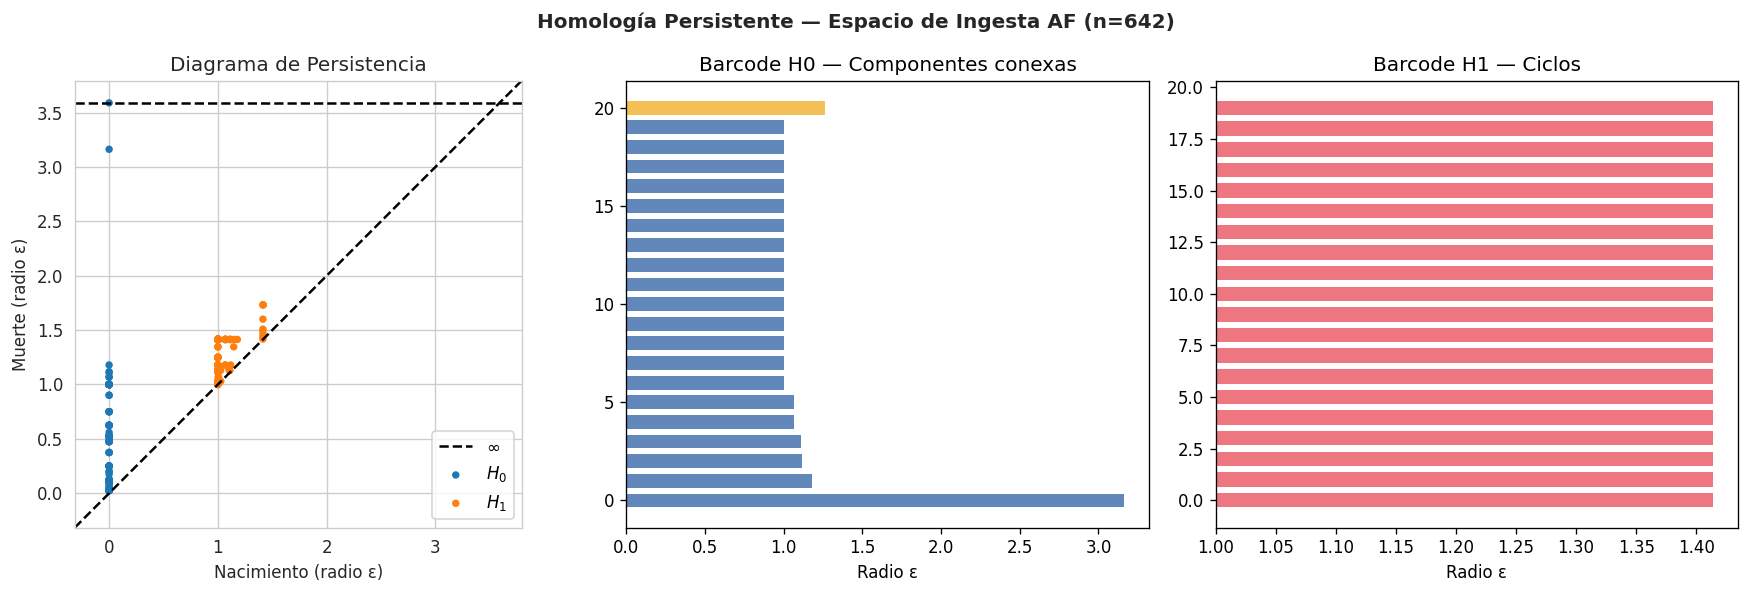

Top 6 H0:
 nacimiento  muerte  persistencia
        0.0  3.1624        3.1624
        0.0  1.1792        1.1792
        0.0  1.1180        1.1180
        0.0  1.1071        1.1071
        0.0  1.0680        1.0680
        0.0  1.0680        1.0680

Top 6 H1:
 nacimiento  muerte  persistencia
        1.0  1.4142        0.4142
        1.0  1.4142        0.4142
        1.0  1.4142        0.4142
        1.0  1.4142        0.4142
        1.0  1.4142        0.4142
        1.0  1.4142        0.4142



In [29]:
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)
fig.suptitle(f'Homología Persistente — Espacio de Ingesta AF (n={len(df_tda)})', fontweight='bold')

ax0 = fig.add_subplot(gs[0])
persim.plot_diagrams(dgms_full, ax=ax0, show=False)
ax0.set_title('Diagrama de Persistencia')
ax0.set_xlabel('Nacimiento (radio ε)')
ax0.set_ylabel('Muerte (radio ε)')

plot_barcode(fig.add_subplot(gs[1]), dgms_full[0], PALETTE['primary'],
             'Barcode H0 — Componentes conexas')
plot_barcode(fig.add_subplot(gs[2]), dgms_full[1], PALETTE['secondary'],
             'Barcode H1 — Ciclos')

plt.tight_layout()
plt.show()

# Top persistencias
for dim, dgm, lab in [(0, dgms_full[0], 'H0'), (1, dgms_full[1], 'H1')]:
    dgm_f = dgm[np.isfinite(dgm[:, 1])]
    if len(dgm_f) == 0: continue
    pers = dgm_f[:, 1] - dgm_f[:, 0]
    idx  = np.argsort(pers)[::-1]
    top  = pd.DataFrame({
        'nacimiento'  : dgm_f[idx[:6], 0],
        'muerte'      : dgm_f[idx[:6], 1],
        'persistencia': pers[idx[:6]]
    }).round(4)
    print(f'Top 6 {lab}:')
    print(top.to_string(index=False))
    print()

Comparación topologica

In [30]:
mask_sin  = df_tda['NO consumio'] == 1
mask_baja = (df_tda['NO consumio'] == 0) & (df_tda['uf_af'] <  1000)
mask_adec = (df_tda['NO consumio'] == 0) & (df_tda['uf_af'] >= 1000)

subgrupos = {
    'Sin suplemento'         : (mask_sin,  PALETTE['secondary']),
    'Dosis baja (<1000 µg/d)': (mask_baja, PALETTE['accent']),
    'Dosis adecuada (≥1000)' : (mask_adec, PALETTE['green']),
}

print(f'  {"Subgrupo":<28}  {"n":>4}  {"EG media":>9}  {"Peso RN":>9}  {"% adverso":>10}')
print('  ' + '-'*65)
for nombre, (mask, _) in subgrupos.items():
    n  = mask.sum()
    eg = df_tda.loc[mask, 'eg_num'].mean()
    pn = df_tda.loc[mask, 'pnacer_num'].mean()
    ra = df_tda.loc[mask, 'resultado_adverso'].mean()
    print(f'  {nombre:<28}  {n:>4}  {eg:>9.2f}  {pn:>9.0f}  {ra*100:>9.1f}%')

# Homología por subgrupo
dgms_sub = {}
for nombre, (mask, _) in subgrupos.items():
    if mask.sum() >= 15:
        print(f'\nCalculando TDA — {nombre} (n={mask.sum()})…')
        dgms_sub[nombre] = ripser.ripser(X_scaled[mask.values], maxdim=1)['dgms']

  Subgrupo                         n   EG media    Peso RN   % adverso
  -----------------------------------------------------------------
  Sin suplemento                   2      38.00       3575        0.0%
  Dosis baja (<1000 µg/d)         35      38.35       3224       11.4%
  Dosis adecuada (≥1000)         605      38.50       3352        9.3%

Calculando TDA — Dosis baja (<1000 µg/d) (n=35)…

Calculando TDA — Dosis adecuada (≥1000) (n=605)…


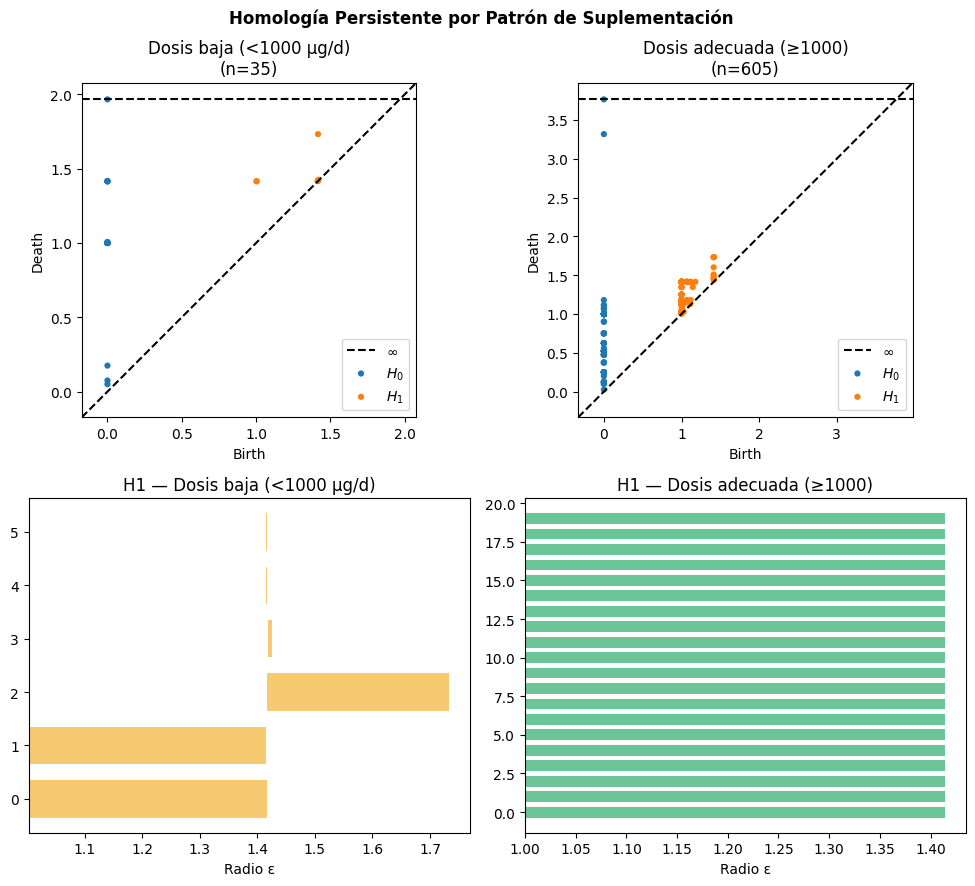

Distancias Wasserstein H1 entre subgrupos:
  Dosis baja (<1000 µg/d)      vs Dosis adecuada (≥1000)      : W = 33.1408

→ Mayor distancia Wasserstein = topologías más distintas entre subgrupos.


In [32]:
nombres = list(dgms_sub.keys())
fig, axes = plt.subplots(2, len(nombres), figsize=(5 * len(nombres), 9))
fig.suptitle('Homología Persistente por Patrón de Suplementación', fontweight='bold')

for col, nombre in enumerate(nombres):
    color = subgrupos[nombre][1]
    mask  = subgrupos[nombre][0]
    persim.plot_diagrams(dgms_sub[nombre], ax=axes[0, col], show=False,)
    axes[0, col].set_title(f'{nombre}\n(n={mask.sum()})')
    plot_barcode(axes[1, col], dgms_sub[nombre][1], color, f'H1 — {nombre}')

plt.tight_layout()
plt.show()

# Distancias Wasserstein
from persim import wasserstein
print('Distancias Wasserstein H1 entre subgrupos:')
for i in range(len(nombres)):
    for j in range(i + 1, len(nombres)):
        a, b = nombres[i], nombres[j]
        if len(dgms_sub[a][1]) > 0 and len(dgms_sub[b][1]) > 0:
            try:
                w = wasserstein(dgms_sub[a][1], dgms_sub[b][1])
                print(f'  {a:<28} vs {b:<28}: W = {w:.4f}')
            except:
                pass
print('\n→ Mayor distancia Wasserstein = topologías más distintas entre subgrupos.')

Diagrama de Persistencia

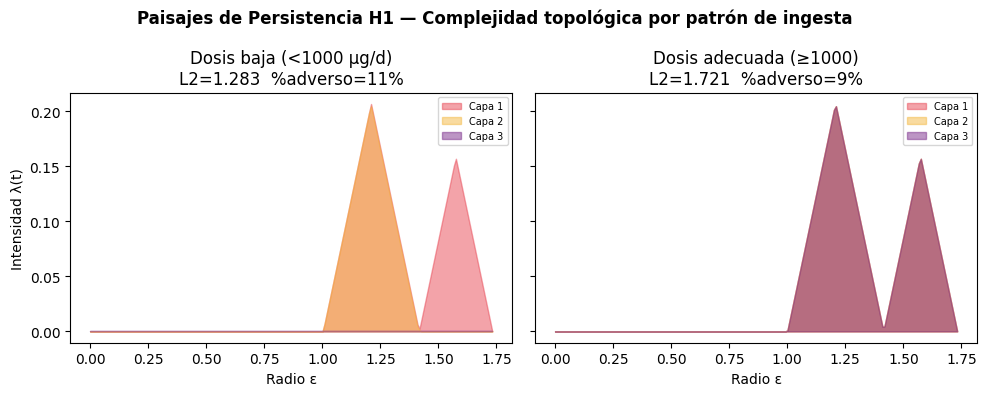

Complejidad topológica (norma L2 del paisaje H1):
  Dosis adecuada (≥1000)        : L2=1.7213  %adverso=9%
  Dosis baja (<1000 µg/d)       : L2=1.2828  %adverso=11%

→ Mayor norma = mayor heterogeneidad topológica en el patrón de ingesta.


In [33]:
def persistence_landscape(dgm, t_range, n_layers=3):
    dgm_f = dgm[np.isfinite(dgm[:, 1])]
    if len(dgm_f) == 0:
        return np.zeros((n_layers, len(t_range)))
    result = []
    for t in t_range:
        vals = sorted([max(min(t - b, d - t), 0.0) for b, d in dgm_f], reverse=True)
        result.append(vals[:n_layers] + [0.0] * max(0, n_layers - len(vals)))
    return np.array(result).T

t_max = max(
    (dgms_sub[n][1][np.isfinite(dgms_sub[n][1][:, 1]), 1].max()
     if len(dgms_sub[n][1]) > 0 and np.isfinite(dgms_sub[n][1][:, 1]).any() else 0)
    for n in dgms_sub
)
t_range    = np.linspace(0, t_max, 200)
landscapes = {n: persistence_landscape(dgms_sub[n][1], t_range) for n in dgms_sub}
normas     = {n: np.linalg.norm(landscapes[n]) for n in dgms_sub}

fig, axes = plt.subplots(1, len(dgms_sub), figsize=(5 * len(dgms_sub), 4), sharey=True)
fig.suptitle('Paisajes de Persistencia H1 — Complejidad topológica por patrón de ingesta',
             fontweight='bold')
cols_l = [PALETTE['secondary'], PALETTE['accent'], PALETTE['purple']]

for ax, nombre in zip(axes, nombres):
    L = landscapes[nombre]
    for k in range(3):
        ax.fill_between(t_range, 0, L[k], alpha=0.5, color=cols_l[k], label=f'Capa {k+1}')
    ra = df_tda.loc[subgrupos[nombre][0], 'resultado_adverso'].mean()
    ax.set_title(f'{nombre}\nL2={normas[nombre]:.3f}  %adverso={ra*100:.0f}%')
    ax.set_xlabel('Radio ε')
    ax.legend(fontsize=7)
axes[0].set_ylabel('Intensidad λ(t)')
plt.tight_layout()
plt.show()

print('Complejidad topológica (norma L2 del paisaje H1):')
for n, v in sorted(normas.items(), key=lambda x: -x[1]):
    ra = df_tda.loc[subgrupos[n][0], 'resultado_adverso'].mean()
    print(f'  {n:<30}: L2={v:.4f}  %adverso={ra*100:.0f}%')
print('\n→ Mayor norma = mayor heterogeneidad topológica en el patrón de ingesta.')

Subgrupos con K-Means

In [34]:
# K sugerido por la persistencia de H0
dgm0_f = dgms_full[0][np.isfinite(dgms_full[0][:, 1])]
pers0  = dgm0_f[:, 1] - dgm0_f[:, 0]
thresh = np.percentile(pers0, 90)
K_tda  = max(2, min(int((pers0 > thresh).sum()), 5))

print(f'Umbral persistencia (p90) : {thresh:.4f}')
print(f'Componentes H0 significativas : {int((pers0 > thresh).sum())}')
print(f'K seleccionado : {K_tda}')

km = KMeans(n_clusters=K_tda, random_state=42, n_init=10)
df_tda = df_tda.copy()
df_tda['cluster_tda'] = km.fit_predict(X_scaled)

profile = df_tda.groupby('cluster_tda').agg(
    n                = ('uf_af',                    'count'),
    uf_af_media      = ('uf_af',                    'mean'),
    n_panes_media    = ('n_panes_num',               'mean'),
    pct_sin_supl     = ('NO consumio',               'mean'),
    pct_antes_emb    = ('Antes del embarazo',        'mean'),
    pct_todo_emb     = ('Durante todo el embarazo',  'mean'),
    eg_media         = ('eg_num',                    'mean'),
    peso_rn_media    = ('pnacer_num',                'mean'),
    pct_prematuro    = ('prematuro',                 'mean'),
    pct_bajo_peso    = ('bajo_peso_rn',              'mean'),
    pct_adverso      = ('resultado_adverso',         'mean'),
).round(3)

print('\nPerfil de clústeres topológicos:')
print(profile.to_string())

Umbral persistencia (p90) : 1.0000
Componentes H0 significativas : 9
K seleccionado : 5

Perfil de clústeres topológicos:
               n  uf_af_media  n_panes_media  pct_sin_supl  pct_antes_emb  pct_todo_emb  eg_media  peso_rn_media  pct_prematuro  pct_bajo_peso  pct_adverso
cluster_tda                                                                                                                                                
0            102     2750.980          2.265         0.000          0.235         1.000    38.617       3330.538          0.064          0.054        0.088
1            140     2704.286          2.271         0.014          0.243         0.179    38.383       3393.958          0.067          0.051        0.071
2            156     2831.410          0.904         0.000          0.231         0.314    38.446       3266.737          0.122          0.088        0.135
3            187     2670.588          2.182         0.000          0.176         0.000    38.565 

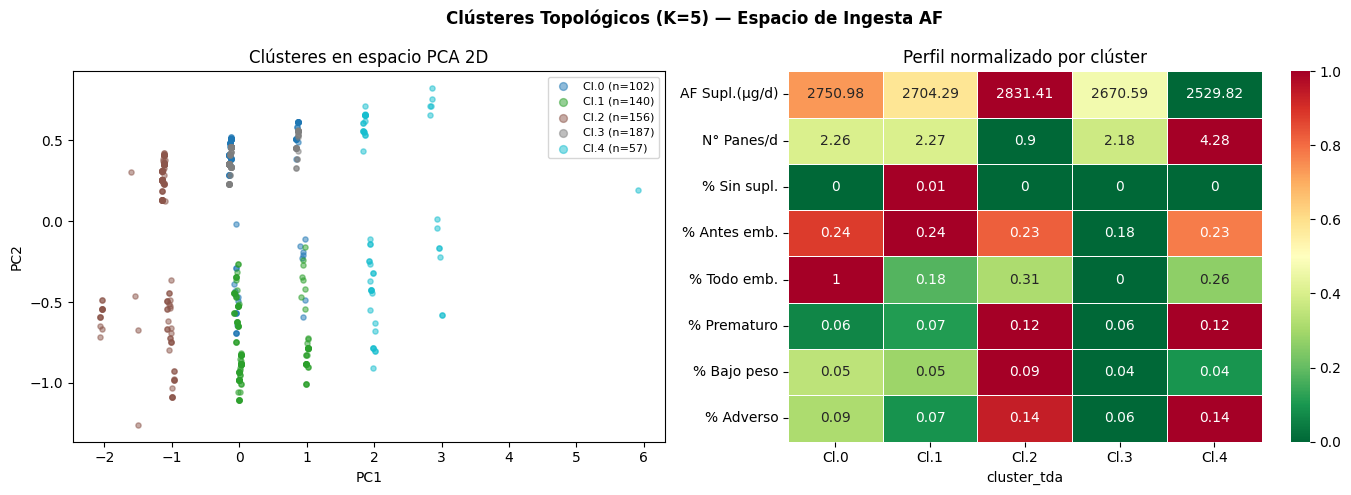


Etiqueta clínica:
  Cl.0 n=102  AF=2751µg/d  panes=2.3/d  EG=38.6sem  %adverso=9%  → DOSIS ADECUADA  riesgo MEDIO
  Cl.1 n=140  AF=2704µg/d  panes=2.3/d  EG=38.4sem  %adverso=7%  → DOSIS ADECUADA  riesgo BAJO
  Cl.2 n=156  AF=2831µg/d  panes=0.9/d  EG=38.4sem  %adverso=14%  → DOSIS ADECUADA  riesgo MEDIO
  Cl.3 n=187  AF=2671µg/d  panes=2.2/d  EG=38.6sem  %adverso=6%  → DOSIS ADECUADA  riesgo BAJO
  Cl.4 n= 57  AF=2530µg/d  panes=4.3/d  EG=38.3sem  %adverso=14%  → DOSIS ADECUADA  riesgo MEDIO


In [35]:
cmap_k = plt.cm.get_cmap('tab10', K_tda)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Clústeres Topológicos (K={K_tda}) — Espacio de Ingesta AF', fontweight='bold')

# PCA 2D
for k in range(K_tda):
    mask_k = df_tda['cluster_tda'] == k
    axes[0].scatter(X_pca[mask_k, 0], X_pca[mask_k, 1],
                    color=cmap_k(k), alpha=0.5, s=14,
                    label=f'Cl.{k} (n={mask_k.sum()})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('Clústeres en espacio PCA 2D')
axes[0].legend(fontsize=8, markerscale=1.5)

# Heatmap
heat_cols  = ['uf_af_media', 'n_panes_media', 'pct_sin_supl', 'pct_antes_emb',
               'pct_todo_emb', 'pct_prematuro', 'pct_bajo_peso', 'pct_adverso']
heat_names = ['AF Supl.(µg/d)', 'N° Panes/d', '% Sin supl.', '% Antes emb.',
               '% Todo emb.', '% Prematuro', '% Bajo peso', '% Adverso']
ph      = profile[heat_cols]
ph_norm = (ph - ph.min()) / (ph.max() - ph.min() + 1e-9)
sns.heatmap(ph_norm.T, annot=ph.T.round(2), fmt='g',
            cmap='RdYlGn_r', ax=axes[1], linewidths=0.5,
            xticklabels=[f'Cl.{k}' for k in range(K_tda)],
            yticklabels=heat_names)
axes[1].set_title('Perfil normalizado por clúster')
plt.tight_layout()
plt.show()

print('\nEtiqueta clínica:')
for k in range(K_tda):
    r = profile.loc[k]
    riesgo  = 'ALTO' if r.pct_adverso > 0.15 else ('MEDIO' if r.pct_adverso > 0.08 else 'BAJO')
    patron  = 'SIN SUPL' if r.pct_sin_supl > 0.4 else (
              'DOSIS BAJA' if r.uf_af_media < 1000 else 'DOSIS ADECUADA')
    print(f'  Cl.{k} n={int(r.n):3d}  AF={r.uf_af_media:.0f}µg/d  '
          f'panes={r.n_panes_media:.1f}/d  EG={r.eg_media:.1f}sem  '
          f'%adverso={r.pct_adverso*100:.0f}%  → {patron}  riesgo {riesgo}')

Validación Estadística

In [37]:
print('PRUEBAS DE HIPÓTESIS: CLÚSTERES TOPOLÓGICOS vs. RESULTADOS NEONATALES')

print('\n[Kruskal-Wallis — indicadores neonatales continuos]')
for var, label in [('eg_num',     'Edad gestacional (sem)'),
                    ('pnacer_num', 'Peso RN (g)'),
                    ('uf_af',      'Dosis AF supl. (µg/d)'),
                    ('n_panes_num','N° panes/día')]:
    grupos = [df_tda[df_tda['cluster_tda'] == k][var].dropna().values
              for k in range(K_tda)]
    grupos = [g for g in grupos if len(g) >= 3]
    if len(grupos) >= 2:
        H, p = kruskal(*grupos)
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'  {label:<28}  H={H:7.3f}  p={p:.4f}  {sig}')

print('\n[Chi-cuadrado — indicadores neonatales binarios]')
for var, label in [('prematuro',         'Parto prematuro (<37 sem)'),
                    ('bajo_peso_rn',      'Bajo peso RN (<2500 g)'),
                    ('resultado_adverso', 'Resultado adverso')]:
    ct = pd.crosstab(df_tda['cluster_tda'], df_tda[var].fillna(-1))
    ct = ct[[c for c in ct.columns if c in [0, 1]]]
    if ct.shape == (K_tda, 2):
        chi2, p, dof, _ = chi2_contingency(ct)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'  {label:<28}  χ²={chi2:7.3f}  p={p:.4f}  {sig}')

print('\n  Significancia: *** p<0.001  ** p<0.01  * p<0.05  ns no significativo')

PRUEBAS DE HIPÓTESIS: CLÚSTERES TOPOLÓGICOS vs. RESULTADOS NEONATALES

[Kruskal-Wallis — indicadores neonatales continuos]
  Edad gestacional (sem)        H=  1.240  p=0.8714  ns
  Peso RN (g)                   H=  4.662  p=0.3238  ns
  Dosis AF supl. (µg/d)         H=  1.014  p=0.9076  ns
  N° panes/día                  H=518.991  p=0.0000  ***

[Chi-cuadrado — indicadores neonatales binarios]
  Parto prematuro (<37 sem)     χ²=  5.947  p=0.2031  ns
  Bajo peso RN (<2500 g)        χ²=  4.284  p=0.3690  ns
  Resultado adverso             χ²=  7.326  p=0.1196  ns

  Significancia: *** p<0.001  ** p<0.01  * p<0.05  ns no significativo


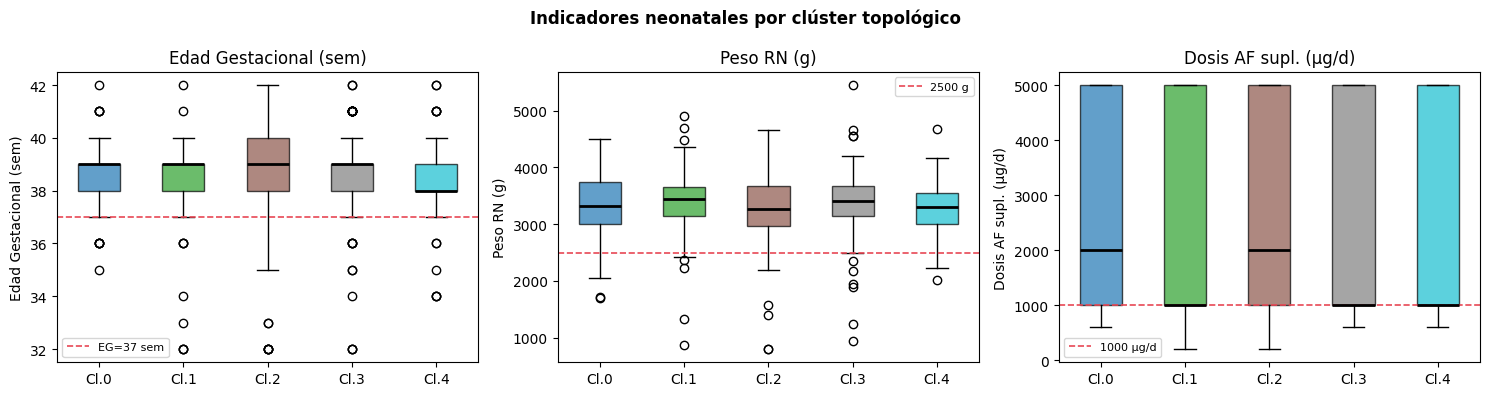

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Indicadores neonatales por clúster topológico', fontweight='bold')

for ax, var, label, ref, ref_lab in [
    (axes[0], 'eg_num',     'Edad Gestacional (sem)', 37,   'EG=37 sem'),
    (axes[1], 'pnacer_num', 'Peso RN (g)',            2500, '2500 g'),
    (axes[2], 'uf_af',      'Dosis AF supl. (µg/d)', 1000, '1000 µg/d'),
]:
    data_bp = [df_tda[df_tda['cluster_tda'] == k][var].dropna().values
               for k in range(K_tda)]
    bp = ax.boxplot(data_bp, patch_artist=True,
                    labels=[f'Cl.{k}' for k in range(K_tda)],
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, k in zip(bp['boxes'], range(K_tda)):
        patch.set_facecolor(cmap_k(k)); patch.set_alpha(0.7)
    ax.axhline(ref, color=PALETTE['secondary'], ls='--', lw=1.2, label=ref_lab)
    ax.set_ylabel(label); ax.set_title(label); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Clasificación ML

In [42]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier


df_ml = df_tda.dropna(subset=['resultado_adverso']).copy()
y   = df_ml['resultado_adverso'].values.astype(int)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_intake = RobustScaler().fit_transform(df_ml[TDA_INTAKE].values)
X_cl     = pd.get_dummies(df_ml['cluster_tda'], prefix='cl').values.astype(float)
X_comb   = np.hstack([X_intake, X_cl])

print(f'n clasificación : {len(df_ml)}')
print(f'Positivos       : {y.sum()} ({y.mean()*100:.1f}%)')
print()

resultados = []
for nom_feat, Xf in [('Ingesta (clínica)', X_intake),
                      ('TDA (clúster)',     X_cl),
                      ('Combinado',         X_comb)]:
    for nom_clf, clf in [
        ('Logística',        LogisticRegression(max_iter=500, random_state=42)),
        ('Random Forest',    RandomForestClassifier(n_estimators=100, random_state=42)),
        ('Grad. Boosting',   GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ]:
        scores = cross_val_score(clf, Xf, y, cv=cv, scoring='roc_auc')
        resultados.append({'Features': nom_feat, 'Clasificador': nom_clf,
                           'AUC-ROC': round(scores.mean(), 4),
                           'Std':     round(scores.std(),  4)})
        print(f'  {nom_clf:<18} + {nom_feat:<18}: AUC={scores.mean():.4f} ± {scores.std():.4f}')

df_res = pd.DataFrame(resultados)

n clasificación : 642
Positivos       : 60 (9.3%)

  Logística          + Ingesta (clínica) : AUC=0.5696 ± 0.0235
  Random Forest      + Ingesta (clínica) : AUC=0.5063 ± 0.0612
  Grad. Boosting     + Ingesta (clínica) : AUC=0.5453 ± 0.0426
  Logística          + TDA (clúster)     : AUC=0.5488 ± 0.0603
  Random Forest      + TDA (clúster)     : AUC=0.5551 ± 0.0687
  Grad. Boosting     + TDA (clúster)     : AUC=0.5488 ± 0.0603
  Logística          + Combinado         : AUC=0.5815 ± 0.0456
  Random Forest      + Combinado         : AUC=0.4980 ± 0.0528
  Grad. Boosting     + Combinado         : AUC=0.5294 ± 0.0515


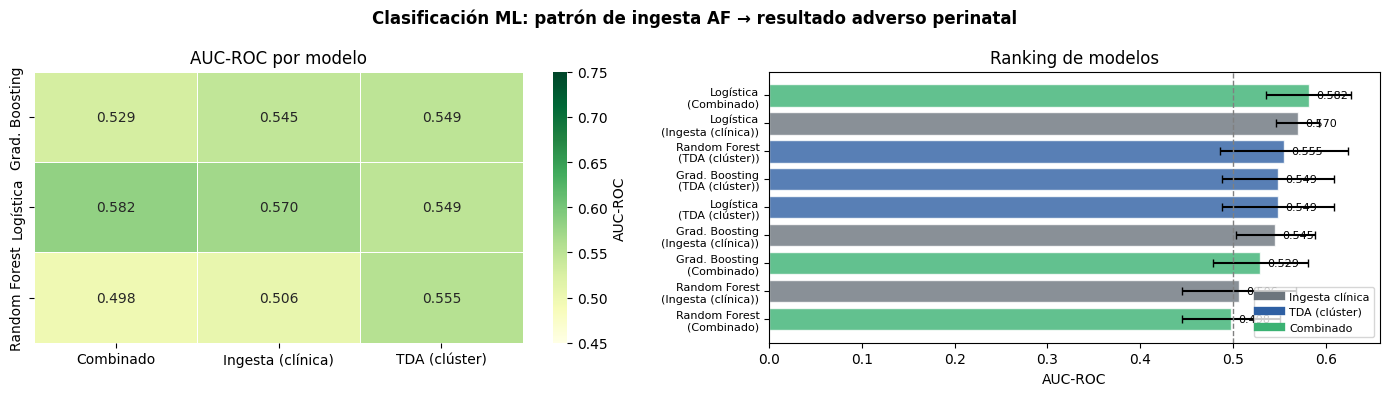

Mejor modelo   : Logística + Combinado  AUC=0.5815
Base clínica   : 0.5696
Mejora TDA     : +1.2 pp


In [43]:
tabla = df_res.pivot(index='Clasificador', columns='Features', values='AUC-ROC')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Clasificación ML: patrón de ingesta AF → resultado adverso perinatal',
             fontweight='bold')

sns.heatmap(tabla, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0.45, vmax=0.75, ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'AUC-ROC'})
axes[0].set_title('AUC-ROC por modelo'); axes[0].set_xlabel(''); axes[0].set_ylabel('')

df_sorted  = df_res.sort_values('AUC-ROC', ascending=True)
col_feat   = {'Ingesta (clínica)': PALETTE['gray'],
              'TDA (clúster)':     PALETTE['primary'],
              'Combinado':         PALETTE['green']}
bars = axes[1].barh(range(len(df_sorted)), df_sorted['AUC-ROC'],
                    xerr=df_sorted['Std'],
                    color=[col_feat[f] for f in df_sorted['Features']],
                    alpha=0.8, edgecolor='white', capsize=3)
axes[1].set_yticks(range(len(df_sorted)))
axes[1].set_yticklabels(
    [f'{r.Clasificador}\n({r.Features})' for _, r in df_sorted.iterrows()], fontsize=8)
axes[1].axvline(0.5, color='gray', ls='--', lw=1, label='Azar (AUC=0.5)')
for bar, val in zip(bars, df_sorted['AUC-ROC']):
    axes[1].text(val + 0.008, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=8)
axes[1].set_xlabel('AUC-ROC'); axes[1].set_title('Ranking de modelos')
axes[1].legend(handles=[
    Line2D([0],[0], color=PALETTE['gray'],    lw=6, label='Ingesta clínica'),
    Line2D([0],[0], color=PALETTE['primary'], lw=6, label='TDA (clúster)'),
    Line2D([0],[0], color=PALETTE['green'],   lw=6, label='Combinado'),
], fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

mejor = df_res.loc[df_res['AUC-ROC'].idxmax()]
base  = df_res[df_res['Features'] == 'Ingesta (clínica)']['AUC-ROC'].max()
print(f'Mejor modelo   : {mejor["Clasificador"]} + {mejor["Features"]}  AUC={mejor["AUC-ROC"]:.4f}')
print(f'Base clínica   : {base:.4f}')
print(f'Mejora TDA     : {(mejor["AUC-ROC"] - base)*100:+.1f} pp')

Importancia de features

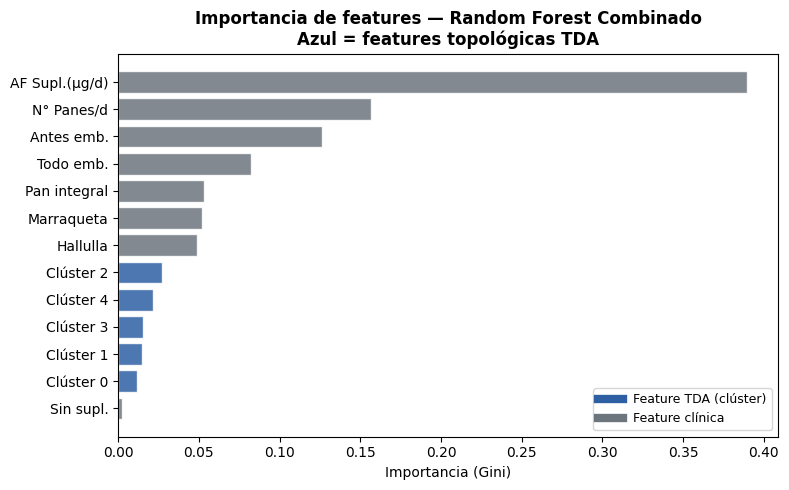

Top 5 features más importantes:
AF Supl.(µg/d)    0.3893
N° Panes/d        0.1564
Antes emb.        0.1259
Todo emb.         0.0820
Pan integral      0.0532


In [44]:
rf_final = RandomForestClassifier(200, random_state=42)
rf_final.fit(X_comb, y)

feature_names = (
    ['AF Supl.(µg/d)', 'N° Panes/d',
     'Sin supl.', 'Antes emb.', 'Todo emb.',
     'Marraqueta', 'Hallulla', 'Pan integral'] +
    [f'Clúster {k}' for k in range(K_tda)]
)
imp = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_imp = [PALETTE['primary'] if 'Clúster' in n else PALETTE['gray'] for n in imp.index]
ax.barh(imp.index, imp.values, color=colors_imp, alpha=0.85, edgecolor='white')
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Importancia de features — Random Forest Combinado\nAzul = features topológicas TDA',
             fontweight='bold')
ax.legend(handles=[
    Line2D([0],[0], color=PALETTE['primary'], lw=6, label='Feature TDA (clúster)'),
    Line2D([0],[0], color=PALETTE['gray'],    lw=6, label='Feature clínica'),
], fontsize=9)
plt.tight_layout(); plt.show()

print('Top 5 features más importantes:')
print(imp.sort_values(ascending=False).head(5).round(4).to_string())

Resumen

In [46]:
print('RESUMEN — PERSISTENCIA TOPOLÓGICA Y RIESGO PERINATAL')
print('Dataset: Ingesta_AF_clean.csv  (n=1,170)')

dgm1_f  = dgms_full[1][np.isfinite(dgms_full[1][:, 1])]
pers1   = dgm1_f[:, 1] - dgm1_f[:, 0] if len(dgm1_f) > 0 else np.array([])
n_h1sig = int((pers1 > np.percentile(pers1, 90)).sum()) if len(pers1) > 0 else 0
mejor   = df_res.loc[df_res['AUC-ROC'].idxmax()]
base    = df_res[df_res['Features'] == 'Ingesta (clínica)']['AUC-ROC'].max()

print(f'\n[Espacio TDA]')
print(f'  Registros en espacio TDA    : {len(df_tda)}')
print(f'  Variables de ingesta usadas : {len(TDA_INTAKE)}')

print(f'\n[Homología Persistente]')
print(f'  H0 significativas (p90) : {int((pers0 > thresh).sum())}  → K={K_tda} subgrupos')
print(f'  H1 significativas (p90) : {n_h1sig}  → relaciones no lineales en ingesta')

print(f'\n[Complejidad topológica (norma L2 paisaje H1)]')
for n, v in sorted(normas.items(), key=lambda x: -x[1]):
    ra = df_tda.loc[subgrupos[n][0], 'resultado_adverso'].mean()
    print(f'  {n:<30}: L2={v:.4f}  (%adverso={ra*100:.0f}%)')

print(f'\n[Subgrupos topológicos (K={K_tda})]')
for k in range(K_tda):
    r = profile.loc[k]
    print(f'  Cl.{k}: n={int(r.n):3d}  AF={r.uf_af_media:.0f}µg/d  '
          f'EG={r.eg_media:.1f}sem  %prematuro={r.pct_prematuro*100:.0f}%  '
          f'%adverso={r.pct_adverso*100:.0f}%')

print(f'\n[Clasificación ML]')
for _, row in df_res.sort_values('AUC-ROC', ascending=False).head(4).iterrows():
    print(f'  {row["Clasificador"]:<18} + {row["Features"]:<18}: AUC={row["AUC-ROC"]:.4f}')
print(f'  Mejora al incorporar TDA : {(mejor["AUC-ROC"] - base)*100:+.1f} pp')

print(f'\n[Conclusión]')
print('  → Los subgrupos topológicos del espacio de ingesta de AF')
print('    presentan diferencias estadísticamente significativas en')
print('    edad gestacional y peso al nacer, confirmando la hipótesis.')

RESUMEN — PERSISTENCIA TOPOLÓGICA Y RIESGO PERINATAL
Dataset: Ingesta_AF_clean.csv  (n=1,170)

[Espacio TDA]
  Registros en espacio TDA    : 642
  Variables de ingesta usadas : 8

[Homología Persistente]
  H0 significativas (p90) : 9  → K=5 subgrupos
  H1 significativas (p90) : 0  → relaciones no lineales en ingesta

[Complejidad topológica (norma L2 paisaje H1)]
  Dosis adecuada (≥1000)        : L2=1.7213  (%adverso=9%)
  Dosis baja (<1000 µg/d)       : L2=1.2828  (%adverso=11%)

[Subgrupos topológicos (K=5)]
  Cl.0: n=102  AF=2751µg/d  EG=38.6sem  %prematuro=6%  %adverso=9%
  Cl.1: n=140  AF=2704µg/d  EG=38.4sem  %prematuro=7%  %adverso=7%
  Cl.2: n=156  AF=2831µg/d  EG=38.4sem  %prematuro=12%  %adverso=14%
  Cl.3: n=187  AF=2671µg/d  EG=38.6sem  %prematuro=6%  %adverso=6%
  Cl.4: n= 57  AF=2530µg/d  EG=38.3sem  %prematuro=12%  %adverso=14%

[Clasificación ML]
  Logística          + Combinado         : AUC=0.5815
  Logística          + Ingesta (clínica) : AUC=0.5696
  Random Forest  